<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
GreenSense: Environmental Sensing System for Optimal Plant Selection
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Recommending Crops By Analyzing Soil and Environmental Factors
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Importing Libraries and Initial Setup
</h1>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [1]:
import math
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, MultiLabelBinarizer,
                                   OneHotEncoder, StandardScaler)
from catboost import CatBoostRanker
from lightgbm import LGBMRanker
from xgboost import XGBRanker

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports Done !")


Imports Done !


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Synthetic Data Generation Based On Research Parameters
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
    Randomly generate data in appropriate format for training models and comparing performance based on research papers and publically available survey information from 2017 to 2019
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [2]:
def weighted_crop_selector(profile, features):
    crops = profile["crops"]
    weights = {crop: 1.0 for crop in crops}

    # Extract features
    temp = features["Env_Temp"]
    humid = features["DHT_Humidity"]
    moisture = features["Soil_Moisture"]
    pH = features["pH"]
    N = features["N"]
    P = features["P"]
    K = features["K"]
    alt = features["BMP_Altitude"]
    season = features["season"]
    district = profile["district"]

    # TEMPERATURE EFFECTS
    if temp > 32:
        for c in ["Mango", "Banana"]:
            weights[c] = weights.get(c, 0) + 3
    if temp < 18:
        for c in ["Wheat", "Onion"]:
            weights[c] = weights.get(c, 0) + 3

    # SOIL MOISTURE EFFECTS
    if moisture > 75:  # Monsoon / waterlogged crops
        for c in ["Rice", "Finger Millet", "Vari", "Coconut"]:
            weights[c] = weights.get(c, 0) + 4

    if moisture < 30:
        for c in ["Groundnut", "Maize", "Bajra"]:
            weights[c] = weights.get(c, 0) + 4

    # HUMIDITY EFFECTS
    if humid > 85:
        for c in ["Rice", "Coconut", "Arecanut"]:
            weights[c] = weights.get(c, 0) + 3

    # pH EFFECTS
    if pH < 6:
        for c in ["Cashew", "Coconut"]:
            weights[c] = weights.get(c, 0) + 2

    if 7 <= pH <= 8:
        for c in ["Grapes", "Onion", "Tomato"]:
            weights[c] = weights.get(c, 0) + 4

    # NUTRIENT EFFECTS
    if N > 260:
        for c in ["Rice", "Wheat"]:
            weights[c] = weights.get(c, 0) + 2

    if K > 250:
        for c in ["Grapes", "Sugarcane"]:
            weights[c] = weights.get(c, 0) + 3

    # ALTITUDE EFFECTS
    if alt > 550:
        for c in ["Grapes", "Finger Millet", "Vegetables"]:
            weights[c] = weights.get(c, 0) + 3

    # SEASON EFFECTS
    if season == "Monsoon":
        for c in ["Rice", "Finger Millet"]:
            weights[c] = weights.get(c, 0) + 3

    if season == "Winter":
        for c in ["Wheat", "Onion"]:
            weights[c] = weights.get(c, 0) + 3

    if season == "Summer":
        for c in ["Mango", "Sugarcane"]:
            weights[c] = weights.get(c, 0) + 3

    # Normalize and choose final crops
    crop_list = list(weights.keys())
    crop_weights = np.array(list(weights.values()), dtype=float)

    crop_weights = np.maximum(crop_weights, 0.01)  # avoid zeros
    crop_weights = crop_weights / crop_weights.sum()

    # choose 1–3 crops
    num_crops = np.random.choice([1,2,3], p=[0.7, 0.2, 0.1])

    selected = np.random.choice(
        crop_list,
        size=num_crops,
        replace=False,
        p=crop_weights
    )

    return ", ".join(selected)



# 2) MAIN SYNTHETIC DATA GENERATOR

def generate_realistic_agri_data(
    num_rows=2500,
    noise_level=0.05,
    null_fraction=0.04,
    all_null_rows_fraction=0.005,
    half_null_rows_fraction=0.01,
    anomaly_rate=0.02,
    extreme_outlier_rate=0.005,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # PROFILES
    profiles = [
        {
            "district": "Raigad",
            "location": "Karjat",
            "altitude_range": (50, 65),
            "pressure_range": (1004, 1008),
            "ph_range": (5.5, 6.0),
            "n_dist": {"mean": 270, "std": 25},
            "p_dist": {"mean": 8, "std": 2},
            "k_dist": {"mean": 220, "std": 20},
            "annual_temp_range": (16, 38),
            "base_temp": 27.5,
            "monsoon_humidity_range": (85, 98),
            "crops": ["Rice", "Ragi", "Vari", "Mango", "Cashew", "Coconut", "Green Gram"],
        },
        {
            "district": "Raigad",
            "location": "Alibag/Mangaon",
            "altitude_range": (5, 15),
            "pressure_range": (1008, 1012),
            "ph_range": (5.5, 6.2),
            "n_dist": {"mean": 285, "std": 30},
            "p_dist": {"mean": 10, "std": 3},
            "k_dist": {"mean": 230, "std": 25},
            "annual_temp_range": (18, 36),
            "base_temp": 27,
            "monsoon_humidity_range": (90, 98),
            "crops": ["Rice", "Coconut", "Arecanut", "Mango", "Cashew", "Banana"],
        },
        {
            "district": "Nashik",
            "location": "Niphad/Yeola",
            "altitude_range": (560, 580),
            "pressure_range": (945, 955),
            "ph_range": (7.0, 7.8),
            "n_dist": {"mean": 230, "std": 25},
            "p_dist": {"mean": 25, "std": 5},
            "k_dist": {"mean": 270, "std": 30},
            "annual_temp_range": (10, 42),
            "base_temp": 27.5,
            "monsoon_humidity_range": (70, 85),
            "crops": ["Grapes", "Onion", "Pomegranate", "Sugarcane", "Tomato", "Wheat"],
        },
        {
            "district": "Nashik",
            "location": "Baglan/Kalwan",
            "altitude_range": (450, 600),
            "pressure_range": (945, 960),
            "ph_range": (6.8, 7.5),
            "n_dist": {"mean": 220, "std": 30},
            "p_dist": {"mean": 45, "std": 8},
            "k_dist": {"mean": 250, "std": 25},
            "annual_temp_range": (14, 42),
            "base_temp": 27.5,
            "monsoon_humidity_range": (75, 90),
            "crops": ["Onion", "Maize", "Bajra", "Grapes", "Mango", "Soybean", "Groundnut"],
        },
        {
            "district": "Nashik",
            "location": "Igatpuri (Ghat Zone)",
            "altitude_range": (600, 900),
            "pressure_range": (940, 950),
            "ph_range": (6.0, 7.0),
            "n_dist": {"mean": 250, "std": 35},
            "p_dist": {"mean": 15, "std": 4},
            "k_dist": {"mean": 180, "std": 30},
            "annual_temp_range": (13, 38),
            "base_temp": 25,
            "monsoon_humidity_range": (85, 100),
            "crops": ["Rice", "Finger Millet", "Maize", "Vegetables"],
        },
    ]

    records = []
    anomaly_flags = []


    # GENERATE ROWS
    for _ in range(num_rows):

        profile = random.choice(profiles)
        day_of_year = random.randint(1,365)

        #  Seasonal temperature 
        temp_amp = (profile['annual_temp_range'][1] -
                   profile['annual_temp_range'][0]) / 2
        env_temp = profile['base_temp'] + temp_amp * math.sin(math.radians(day_of_year - 90))

        #  Season classification 
        if 60 <= day_of_year <= 150:
            season = "Summer"
            humidity = np.random.uniform(20,45)
            light = np.random.uniform(90000,115000)
            soil_moist = np.random.uniform(10,30)
        elif 151 <= day_of_year <= 273:
            season = "Monsoon"
            humidity = np.random.uniform(*profile['monsoon_humidity_range'])
            light = np.random.uniform(15000,55000)
            soil_moist = np.random.uniform(80,98)
        else:
            season = "Winter"
            humidity = np.random.uniform(40,65)
            light = np.random.uniform(60000,90000)
            soil_moist = np.random.uniform(30,55)

        # Irrigated districts
        if profile["district"] == "Nashik" and season != "Monsoon":
            soil_moist = max(soil_moist, np.random.uniform(40,65))

        # RAW SENSOR VALUES
        altitude = np.random.uniform(*profile["altitude_range"])
        pressure = np.random.uniform(*profile["pressure_range"])
        co2 = np.random.uniform(405,425)
        co = np.random.uniform(0.1,5)
        nh3 = np.random.uniform(0.1,4)
        pH = np.random.uniform(*profile["ph_range"])
        N = abs(np.random.normal(profile['n_dist']['mean'], profile['n_dist']['std']))
        P = abs(np.random.normal(profile['p_dist']['mean'], profile['p_dist']['std']))
        K = abs(np.random.normal(profile['k_dist']['mean'], profile['k_dist']['std']))
        soil_temp = env_temp - np.random.uniform(1.5,4)

        #  BUILD BASIC RECORD 
        base = {
            "Env_Temp": env_temp,
            "BMP_Pressure": pressure,
            "BMP_Altitude": altitude,
            "Light": light,
            "DHT_Humidity": humidity,
            "MQ135_CO2": co2,
            "MQ135_CO": co,
            "MQ135_NH3": nh3,
            "Soil_Moisture": soil_moist,
            "Soil_Temp": soil_temp,
            "pH": pH,
            "N": N,
            "P": P,
            "K": K,
            "district": profile["district"],
            "location": profile["location"],
            "season": season
        }

        #  MULTI-LABEL TARGET BASED ON FEATURES 
        target = weighted_crop_selector(profile, base)
        base["target_crops"] = target

        #  Add noise 
        for k in ["Env_Temp","BMP_Pressure","BMP_Altitude","Light","DHT_Humidity",
                  "MQ135_CO2","MQ135_CO","MQ135_NH3","Soil_Moisture",
                  "Soil_Temp","pH","N","P","K"]:
            base[k] *= (1 + np.random.normal(0, noise_level))

        #  Sensor anomalies 
        if np.random.rand() < anomaly_rate:
            f = random.choice(["MQ135_CO2","Light","N","Env_Temp"])
            if f == "MQ135_CO2":
                base[f] = np.random.uniform(250,2000)
            elif f == "Light":
                base[f] = np.random.uniform(200000,800000)
            elif f == "N":
                base[f] = random.choice([0, -abs(np.random.uniform(1,100))])
            elif f == "Env_Temp":
                base[f] = np.random.uniform(-20,60)

        #  Extreme outliers 
        if np.random.rand() < extreme_outlier_rate:
            f = random.choice(["P","K","BMP_Altitude"])
            base[f] *= np.random.uniform(5,25)

        records.append(base)

    df = pd.DataFrame(records)

    #  RANDOM NULLS 
    mask = np.random.rand(*df.shape) < null_fraction
    mask[:, df.columns.get_loc("target_crops")] = False   # NEVER null target
    df = df.mask(mask)

    #  ALL-NULL ROWS except target
    for _ in range(int(all_null_rows_fraction * num_rows)):
        idx = np.random.randint(len(df))
        row_cols = [c for c in df.columns if c != "target_crops"]
        df.loc[idx, row_cols] = np.nan

    #  HALF-NULL ROWS 
    for _ in range(int(half_null_rows_fraction * num_rows)):
        idx = np.random.randint(len(df))
        safe = [c for c in df.columns if c != "target_crops"]
        drop_cols = np.random.choice(safe, size=int(len(safe)*0.55), replace=False)
        df.loc[idx, drop_cols] = np.nan

    return df.reset_index(drop=True)



df_sample = generate_realistic_agri_data(
    num_rows=np.random.randint(5200, 7000),
    noise_level=0.05,
    null_fraction=0.05,
    all_null_rows_fraction=0.01,
    half_null_rows_fraction=0.01,
    anomaly_rate=0.02,
    extreme_outlier_rate=0.005,
    seed=42
)

df_sample.to_csv("synthetic_crop_data.csv", index=False)

df = df_sample.copy()
print("Synthetic data generated and saved to 'synthetic_crop_data.csv'")

Synthetic data generated and saved to 'synthetic_crop_data.csv'


<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
    Due to lack of stnadardized data of soil and environment, synthetic data was generated but with backing of historical values for certain geographical locations (specifically Raigad and Nashik in Maharashtra). This synthetic dataset further adds conditional weighted assignment for <strong>21 distinct crops</strong> and finally adds some noise (invalid and null values) and outliers to make the synthetic dataset realistic for making robust pipeline and setting realistic expectations for the recommendation models.
    </p>
</div>


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
    Data Loading
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
    Optionally, load data as CSV from google drive url.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [3]:
# dataset_id = "1gcT3BLkUZNoM5sTnvazYJ0ecaGaVXh1D"

# url = f"https://drive.google.com/uc?id={dataset_id}"

# df = pd.read_csv(url)
# print(f"Loaded dataframe with shape: {df.shape}")

<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
    Exploratory Data Analysis
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
    Tabular EDA + Graphical EDA to extract knowledge from the numerical and categorical data.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


### > Tabular EDA

---


In [4]:
print("Dataframe Info ###")
df.info()

Dataframe Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Env_Temp       5935 non-null   float64
 1   BMP_Pressure   5922 non-null   float64
 2   BMP_Altitude   5897 non-null   float64
 3   Light          5948 non-null   float64
 4   DHT_Humidity   5955 non-null   float64
 5   MQ135_CO2      5918 non-null   float64
 6   MQ135_CO       5925 non-null   float64
 7   MQ135_NH3      5935 non-null   float64
 8   Soil_Moisture  5922 non-null   float64
 9   Soil_Temp      5945 non-null   float64
 10  pH             5925 non-null   float64
 11  N              5894 non-null   float64
 12  P              5914 non-null   float64
 13  K              5920 non-null   float64
 14  district       5922 non-null   object 
 15  location       5898 non-null   object 
 16  season         5927 non-null   object 
 17  target_crops   6326 non-null   ob

<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        The columns namely:
        <br> 1.  Env_Temp 
        <br> 2.  BMP_Pressure 
        <br> 3.  BMP_Altitude 
        <br> 4.  Light 
        <br> 5.  DHT_Humidity 
        <br> 6.  MQ135_CO2 
        <br> 7.  MQ135_CO 
        <br> 8.  MQ135_NH3 
        <br> 9.  Soil_Moisture 
        <br> 10. Soil_Temp 
        <br> 11. pH 
        <br> 12. N 
        <br> 13. P 
        <br> 14. K
        <br> Are readings directly corresponding to physical soil+environmental analyzer device which is core  of this project, used for profiling.
    </p>
</div>


In [5]:
X_df = df.drop(columns=["target_crops"])
y_df = df["target_crops"]

print("\nDescriptive Statistics for Features")
X_df.describe().T


Descriptive Statistics for Features


,count,mean,std,min,25%,50%,75%,max
Env_Temp,5935.0,26.730094,9.406758,-17.580021,18.417381,26.557074,35.058944,59.736300
BMP_Pressure,5922.0,973.704870,56.231986,776.184987,934.887066,972.640007,1012.187558,1181.951509
BMP_Altitude,5897.0,390.752058,393.424026,4.597404,53.650057,517.467368,596.527086,11233.957722
Light,5948.0,70333.843542,43673.133492,13665.602199,43775.358240,71289.954638,90116.072275,785585.418898
DHT_Humidity,5955.0,59.586772,23.151849,18.568653,41.622466,55.378980,82.265679,110.523574
MQ135_CO2,5918.0,418.822943,63.007916,283.339954,401.104216,415.768649,430.075465,1943.551298
MQ135_CO,5925.0,2.559428,1.417136,0.096065,1.333411,2.557295,3.766311,5.522088
MQ135_NH3,5935.0,2.047653,1.133039,0.090356,1.058815,2.059642,3.011023,4.483939
Soil_Moisture,5922.0,60.514582,23.775527,9.653508,44.403554,55.408411,84.577898,112.997912
Soil_Temp,5945.0,24.003287,9.297718,7.102142,15.773438,23.805896,32.256529,45.858040


In [6]:
print("\nMissing Values Counts")
print(X_df.isnull().sum())


Missing Values Counts
Env_Temp         391
BMP_Pressure     404
BMP_Altitude     429
Light            378
DHT_Humidity     371
MQ135_CO2        408
MQ135_CO         401
MQ135_NH3        391
Soil_Moisture    404
Soil_Temp        381
pH               401
N                432
P                412
K                406
district         404
location         428
season           399
dtype: int64


<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        As the dataset is synthetically generated, it still contains some <strong>invalid values and null values</strong> which adds aspect of reality into the synthetic dataset.
    </p>
</div>


### > Graphical EDA

---


In [7]:
numeric_cols = [
    'Env_Temp',
    'BMP_Pressure',
    'BMP_Altitude',
    'Light',
    'DHT_Humidity',
    'MQ135_CO2',
    'MQ135_CO',
    'MQ135_NH3',
    'Soil_Moisture',
    'Soil_Temp',
    'pH',
    'N',
    'P',
    'K'
]
cat_cols = [c for c in df.columns if c not in numeric_cols]

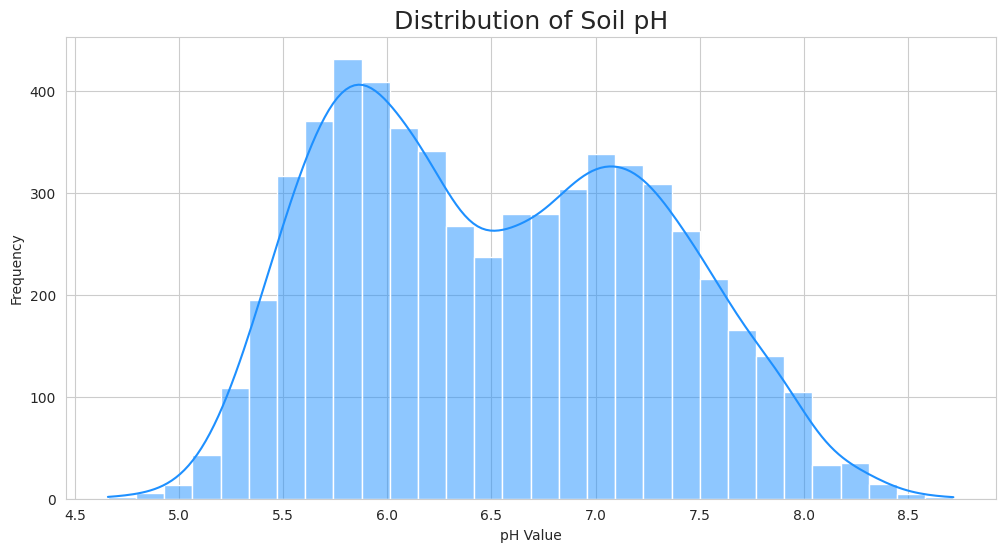

In [8]:
# Graph 1: Distribution of a Key Numerical Feature (e.g., pH)
plt.figure(figsize=(12, 6))
sns.histplot(df['pH'].dropna(), kde=True, bins=30, color='dodgerblue')
plt.title('Distribution of Soil pH', fontsize=18)
plt.xlabel('pH Value')
plt.ylabel('Frequency')
plt.show()

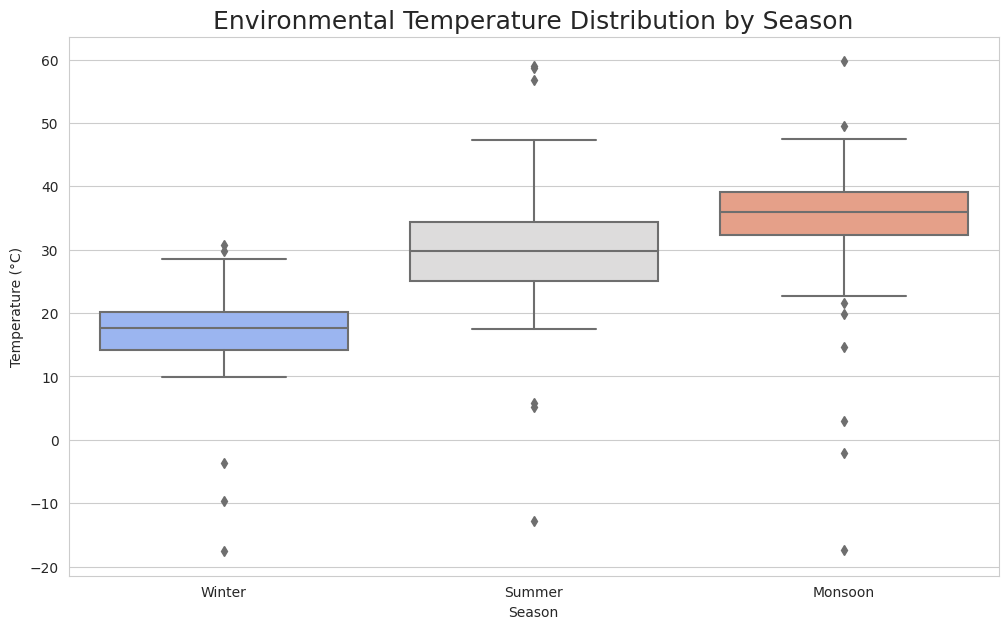

In [9]:
# Graph 2: Distribution of Environmental Temperature by Season
plt.figure(figsize=(12, 7))
sns.boxplot(x='season', y='Env_Temp', data=df, palette='coolwarm')
plt.title('Environmental Temperature Distribution by Season', fontsize=18)
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.show()

<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        Since two distinct geographical locations, are considered, The distribution shows <strong>bimodal distribution for pH.</strong>
        <br>
        The temperature shows usual behavior as <strong>winter < monsoom < summer.</strong>
    </p>
</div>


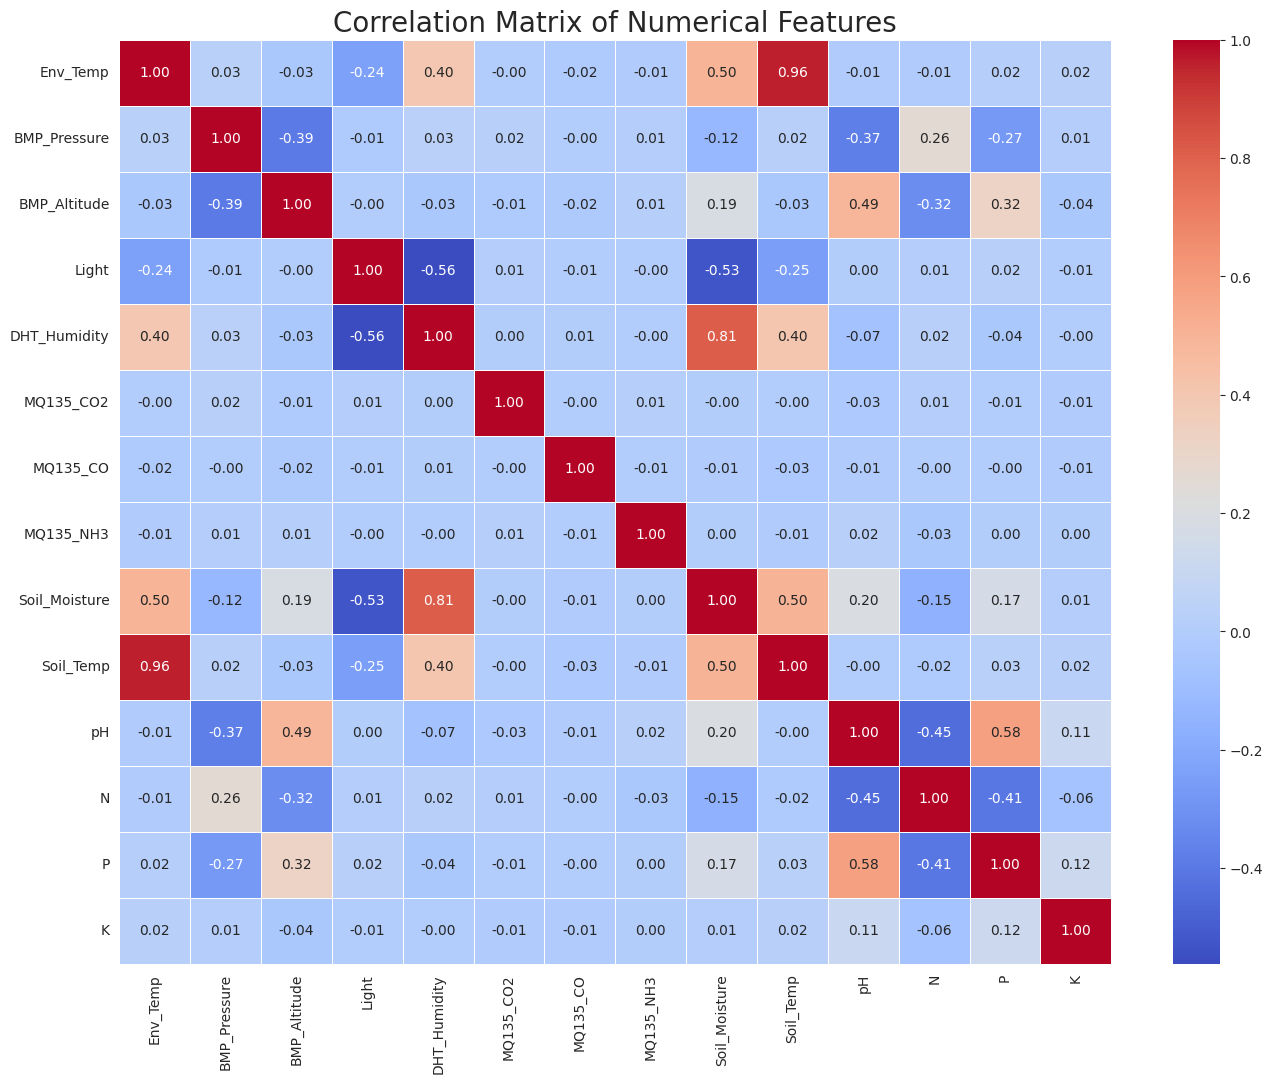

In [10]:
# Graph 3: Correlation Heatmap of Numerical Features
plt.figure(figsize=(16, 12))
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.show()

<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        There is strong correlation between <strong>soil and environmental temperature and soil and environmental humidity.</strong> Other features show moderate to low correlation indicating moderate multi collinearity, potentially problem for linear models but not an issue for tree based models.
    </p>
</div>


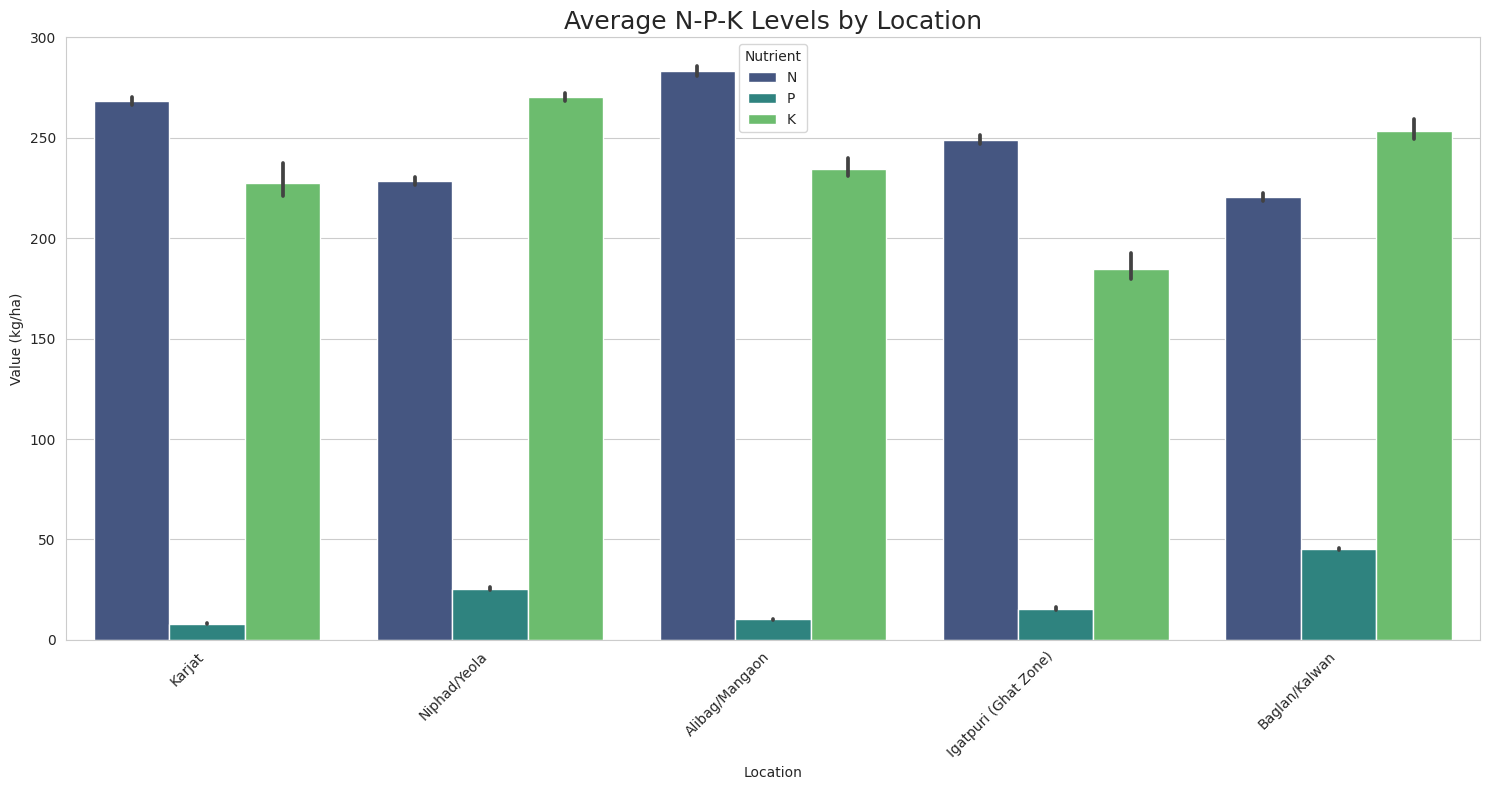

In [11]:
# Graph 4: N, P, K values by Location
plt.figure(figsize=(15, 8))
df_melted = df.melt(id_vars='location', value_vars=['N', 'P', 'K'],
                    var_name='Nutrient', value_name='Value')
sns.barplot(x='location', y='Value', hue='Nutrient',
            data=df_melted, palette='viridis')
plt.title('Average N-P-K Levels by Location', fontsize=18)
plt.xlabel('Location')
plt.ylabel('Value (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

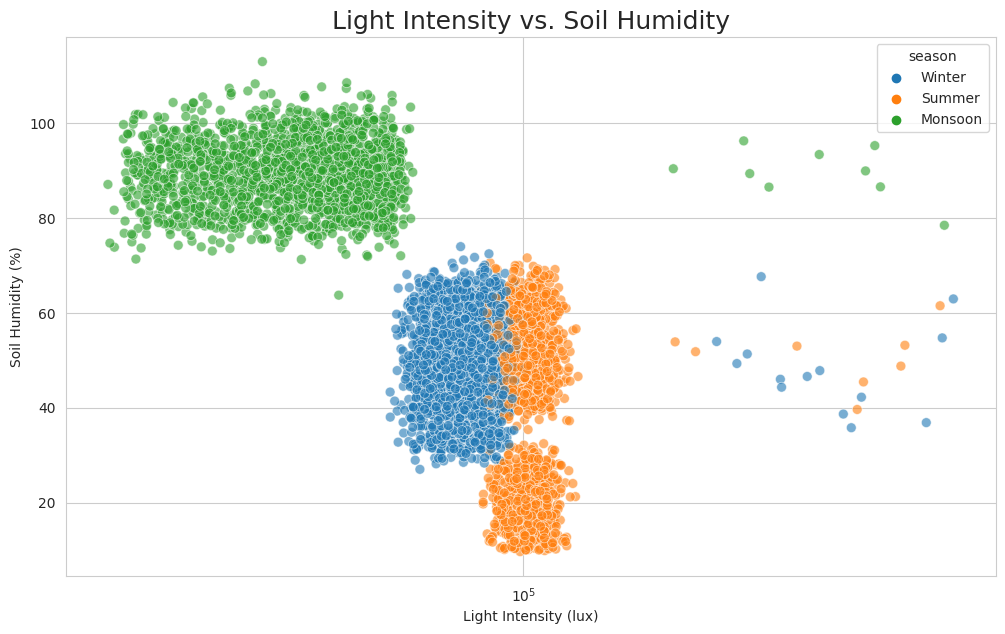

In [12]:
# Graph 5: Light Intensity vs. Soil Humidity
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Light', y='Soil_Moisture',
                data=df, hue='season', alpha=0.6, s=50)
plt.title('Light Intensity vs. Soil Humidity', fontsize=18)
plt.xlabel('Light Intensity (lux)')
plt.ylabel('Soil Humidity (%)')
plt.xscale('log')
plt.show()

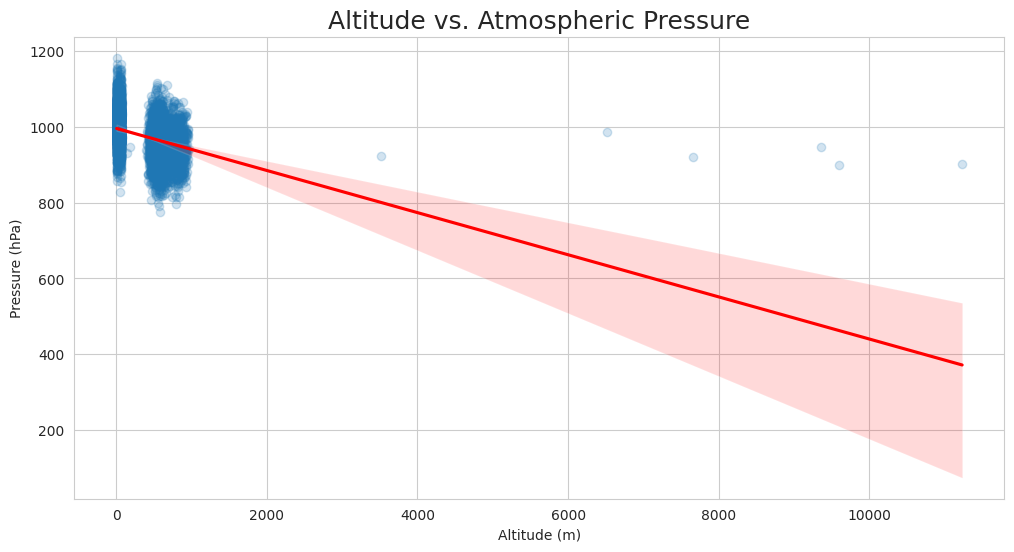

In [13]:
# Graph 6: Altitude vs. Pressure
plt.figure(figsize=(12, 6))
sns.regplot(x='BMP_Altitude', y='BMP_Pressure', data=df,
            scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title('Altitude vs. Atmospheric Pressure', fontsize=18)
plt.xlabel('Altitude (m)')
plt.ylabel('Pressure (hPa)')
plt.show()

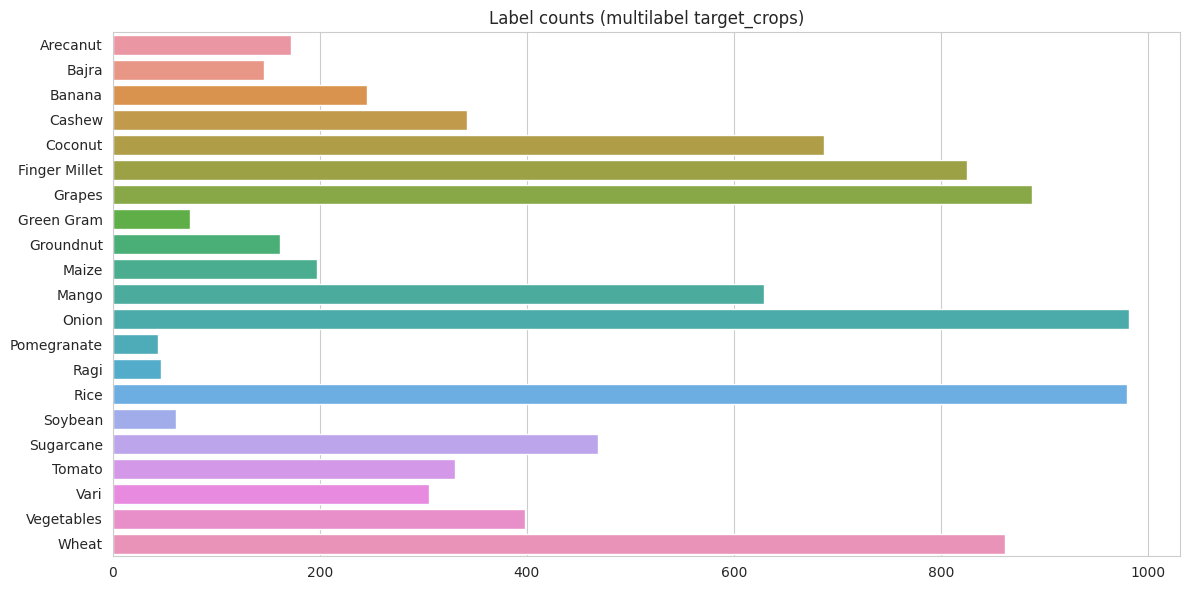

In [14]:
# Graph 7: Bar plot showing target distribution
mlb = MultiLabelBinarizer()
labels = df['target_crops'].dropna().astype(str).apply(
    lambda x: [s.strip() for s in x.split(',')])

ymat = mlb.fit_transform(labels)
counts = ymat.sum(axis=0)

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=mlb.classes_)
plt.title('Label counts (multilabel target_crops)')
plt.tight_layout()
plt.show()

<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        Location district wise column chart of average NPK values shows relation between district and soi nutrients. The light intensity scatter plot shows season wise distribution and some noise/outliers. The altitude vs pressure graph shows regression line for relation between them along with sharp dive for outliers. Finally, the target crop distribution shows most frequent crops: <strong>Grapes, Onion, Rice, Wheat</strong>.
    </p>
</div>


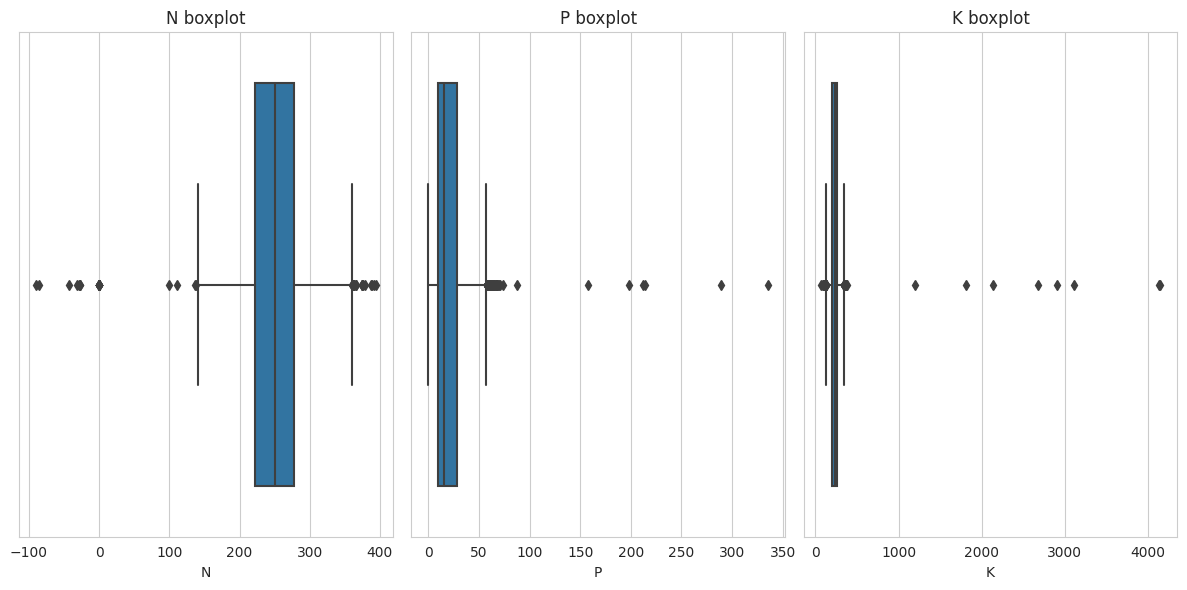

In [15]:
# Graph 8: Boxplots to inspect outliers (N,P,K,pH)
plt.figure(figsize=(12, 6))
for i, col in enumerate(['N', 'P', 'K']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col+' boxplot')
plt.tight_layout()
plt.show()

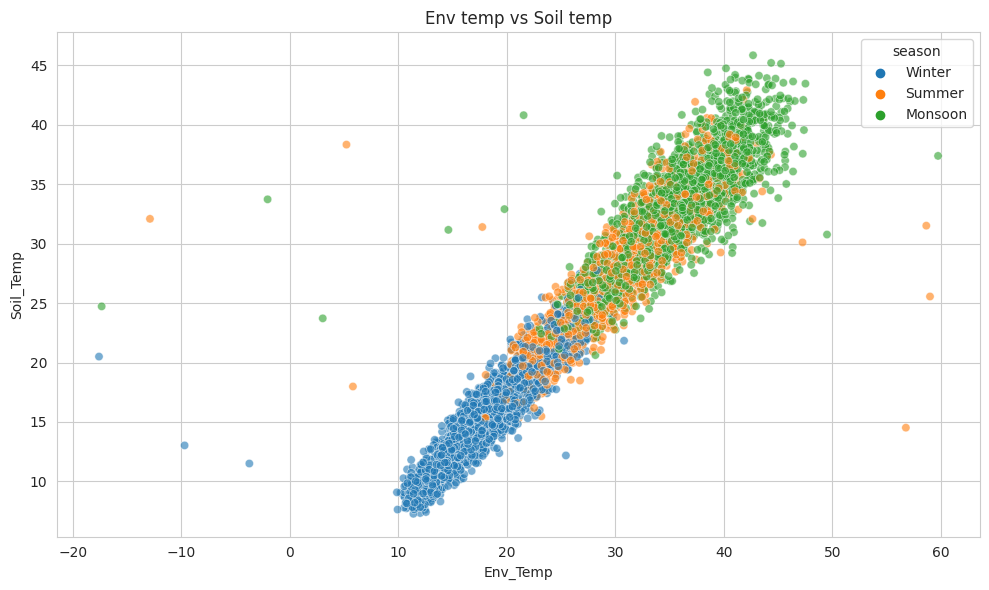

In [16]:
# Graph 9: Scatter plot env_temp vs soil_temp
sns.scatterplot(x='Env_Temp', y='Soil_Temp', hue='season',
                data=df, palette='tab10', alpha=0.6)
plt.title('Env temp vs Soil temp')
plt.tight_layout()
plt.show()

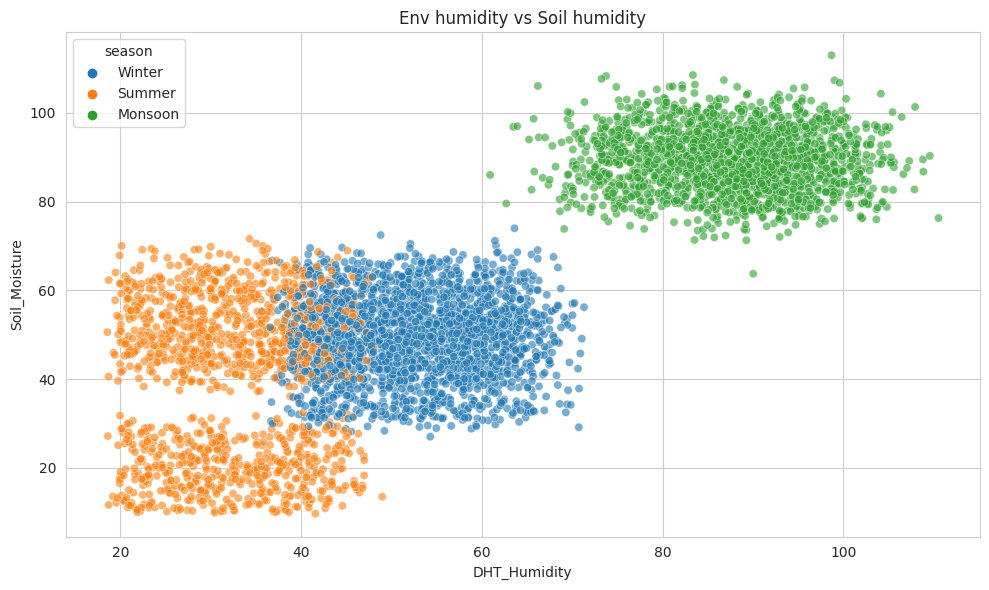

In [17]:
# Graph 10: Scatter plot env_humidity vs soil_humidity
sns.scatterplot(x='DHT_Humidity',
                y='Soil_Moisture', hue='season', data=df, alpha=0.6)
plt.title('Env humidity vs Soil humidity')
plt.tight_layout()
plt.show()

<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        The NPK box plots highlight <strong>invalid values for Nitrogen</strong> present in dataset and outliers in Potassioun (K). For the locations considered in the dataset, the temperature historically never went below 0 degree celcius, thus indicating <strong>invalid values in temperature features</strong>. The humidity shows strung correlation between soil humidity and environmental humidity as expected.
    </p>
</div>


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Data Cleaning
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Sanity checks for certain parameters like N, P, K, Temperature, Humidity, Light Intensity and replacing outliers with null values.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [18]:
def clean_and_clip(df_in):
    df = df_in.copy()
    # Basic validity checks
    try:
        df.loc[df['P'] < 0, 'P'] = np.nan
    except:
        pass
    try:
        df.loc[df['K'] < 0, 'K'] = np.nan
    except:
        pass
    try:
        df.loc[df['N'] < 0, 'N'] = np.nan
    except:
        pass
    try:
        df.loc[df['Env_Temp'] < 0, 'Env_Temp'] = np.nan
    except:
        pass
    try:
        df.loc[df['DHT_Humidity'] > 100, 'DHT_Humidity'] = np.nan
    except:
        pass
    try:
        df.loc[df['Soil_Moisture'] > 100, 'Soil_Moisture'] = np.nan
    except:
        pass
    try:
        df.loc[df['Light'] < 0, 'Light'] = np.nan
    except:
        pass

    # Outlier removal using IQR method
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan

    return df

In [19]:
class RobustLocationImputer(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols=None, min_group_size=5, verbose=False):
        self.numeric_cols = numeric_cols
        self.min_group_size = min_group_size
        self.verbose = verbose

    def fit(self, X, y=None):
        df = X.copy()
        if self.numeric_cols is None:
            self.numeric_cols = df.select_dtypes(
                include=[np.number]).columns.tolist()

        # Compute medians for each level
        self.group_medians_ = (
            df.groupby(["district", "location", "season"])[self.numeric_cols]
            .median(numeric_only=True)
            .dropna(how="all")
        )
        self.district_medians_ = (
            df.groupby("district")[self.numeric_cols]
            .median(numeric_only=True)
            .dropna(how="all")
        )
        self.global_medians_ = df[self.numeric_cols].median(numeric_only=True)
        return self

    def set_output(self, transform=None):
        return self

    def transform(self, X):
        df = X.copy()
        for idx, row in df.iterrows():
            d, l, s = row["district"], row["location"], row["season"]
            group_key = (d, l, s)
            if group_key in self.group_medians_.index:
                group_valid = (
                    len(df[(df["district"] == d) & (
                        df["location"] == l) & (df["season"] == s)])
                    >= self.min_group_size
                )
            else:
                group_valid = False
            for col in self.numeric_cols:
                if pd.isna(row[col]):
                    new_val = None
                    if group_valid and not pd.isna(self.group_medians_.loc[group_key, col]):
                        new_val = self.group_medians_.loc[group_key, col]
                    elif d in self.district_medians_.index and not pd.isna(self.district_medians_.loc[d, col]):
                        new_val = self.district_medians_.loc[d, col]
                    else:
                        new_val = self.global_medians_[col]
                    df.at[idx, col] = new_val
        return df

<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Feature Engineering
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Derived meaningful features by computing nutrient interaction ratios, environmental-soil differentials for temperature and moisture, logarithmic normalization of light intensity, altitude-based categorical bucketing and ordinal season encoding to capture nonlinear relationships.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [20]:
def feature_engineer(df_in):
    df = df_in.copy()

    #  Core nutrient ratios
    df['N_plus_P'] = df['N'] + df['P']
    df['P_over_N'] = df['P'] / (df['N'] + 1e-6)
    df['K_over_N'] = df['K'] / (df['N'] + 1e-6)

    #  Temperature deltas
    df['env_minus_soil_temp'] = df['Env_Temp'] - df['Soil_Temp']

    # Soil moisture replaces old soil_humidity_percent
    df['env_minus_soil_humidity'] = df['DHT_Humidity'] - df['Soil_Moisture']

    #  Log transforms
    df['light_log'] = np.log1p(df['Light'])

    df['alt_bucket'] = pd.cut(
        df['BMP_Altitude'],
        bins=[-1, 100, 300, 600, 1000, 5000],
        labels=['very_low', 'low', 'med', 'high', 'very_high']
    )

    season_map = {s.lower(): i for i, s in enumerate(
        ['summer', 'monsoon', 'winter']
    )}
    df['season_enc'] = df['season'].astype(str).str.lower().map(season_map)

    return df

<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Data Preprocessing
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
preprocessing pipeline including sensor value cleaning and clipping, robust location-aware imputation for missing values, feature engineering, median imputation and standardization of numerical features, one-hot encoding of categorical variables and multilabel binarization of crop targets to ensure a fully numeric, model-ready representation.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [21]:
clean_transformer = FunctionTransformer(clean_and_clip, validate=False)
impute_transformer = RobustLocationImputer(verbose=True)
fe_transformer = FunctionTransformer(feature_engineer, validate=False)

df_tmp = feature_engineer(clean_and_clip(df.copy()))

all_numeric = df_tmp.select_dtypes(
    include=['float64', 'int64', 'float32', 'int32']).columns.tolist()
all_categorical = df_tmp.select_dtypes(
    include=['object', 'category']).columns.tolist()

if 'target_crops' in all_categorical:
    all_categorical.remove('target_crops')

print('Numeric features:', all_numeric)
print('Categorical features:', all_categorical)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

ct = ColumnTransformer(transformers=[
    ('num', numeric_transformer, all_numeric),
    ('cat', categorical_transformer, all_categorical)
], remainder='drop')

preprocessor = Pipeline(steps=[
    ('cleaning', clean_transformer),
    ('robust_impute', impute_transformer),
    ('feature_engineering', fe_transformer),
    ('preprocessor', ct)
]).set_output(transform='pandas')

print("Pipeline created")

Numeric features: ['Env_Temp', 'BMP_Pressure', 'BMP_Altitude', 'Light', 'DHT_Humidity', 'MQ135_CO2', 'MQ135_CO', 'MQ135_NH3', 'Soil_Moisture', 'Soil_Temp', 'pH', 'N', 'P', 'K', 'N_plus_P', 'P_over_N', 'K_over_N', 'env_minus_soil_temp', 'env_minus_soil_humidity', 'light_log', 'season_enc']
Categorical features: ['district', 'location', 'season', 'alt_bucket']
Pipeline created


In [22]:
raw_target = df['target_crops']

mlb = MultiLabelBinarizer()
parsed = raw_target.fillna('').astype(str).apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip() != ''])
Y = mlb.fit_transform(parsed)

target_classes = list(mlb.classes_)


joblib.dump(mlb, f"MLB.joblib")
print(f"Multilabel Binarizer saved as MLB.joblib")

print('Multilabel detected with classes:', target_classes)

Multilabel Binarizer saved as MLB.joblib
Multilabel detected with classes: ['Arecanut', 'Bajra', 'Banana', 'Cashew', 'Coconut', 'Finger Millet', 'Grapes', 'Green Gram', 'Groundnut', 'Maize', 'Mango', 'Onion', 'Pomegranate', 'Ragi', 'Rice', 'Soybean', 'Sugarcane', 'Tomato', 'Vari', 'Vegetables', 'Wheat']


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Train Test Split
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Splitting original dataset into two sets:<br> <em>train</em>: for training ranking recommendation models;
<br> and <br><em>test</em>: for validating performance of models on unseen datasets.

</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [23]:
X = df.drop(columns=['target_crops'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=42)

print('Train / test shapes:', X_train.shape, X_test.shape)

Train / test shapes: (5060, 17) (1266, 17)


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Pipeline Transformation
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Applying all data cleaning, preprocessing, feature engineering through the use of <code>Pipeline</code> to the training and testing dataset. Then saving the <code>Pipeline</code> in joblib format for Flask API use.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [24]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

joblib.dump(preprocessor, f"preprocessing_pipeline.joblib")
print(f"Pipeline saved as preprocessing_pipeline.joblib")

print('Train / test shapes:', X_train_trans.shape, X_test_trans.shape)

Pipeline saved as preprocessing_pipeline.joblib
Train / test shapes: (5060, 35) (1266, 35)


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Model Training
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Preparing data for ranker models and then defining vustom evaluation metrics for recommendation type problem. Training models: XGBRanker, LGBMRanker, CatBoostRanker with default parameters.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [25]:
crop_list = list(mlb.classes_)
n_labels = len(crop_list)

# MAKE RANKING DATA
def make_ranking_data(X, Y, crop_list):
    X_rank, y_rank, groups = [], [], []

    for i in range(X.shape[0]):
        x_row = X[i]
        true_labels = Y[i]
        
        for j in range(len(crop_list)):
            crop_id_vec = np.eye(len(crop_list))[j]
            feat = np.concatenate([x_row, crop_id_vec])
            X_rank.append(feat)
            y_rank.append(true_labels[j])

        groups.append(len(crop_list))

    return (
        np.array(X_rank, dtype=np.float32),
        np.array(y_rank, dtype=np.int32),
        np.array(groups, dtype=np.int32)
    )
X_train_np = X_train_trans.to_numpy()
X_test_np  = X_test_trans.to_numpy()

Y_train_np = np.array(Y_train)
Y_test_np  = np.array(Y_test)


X_train_rank, y_train_rank, groups_train = make_ranking_data(X_train_np, Y_train_np, crop_list)
X_test_rank, y_test_rank, groups_test = make_ranking_data(X_test_np, Y_test_np, crop_list)

In [26]:
# PREDICT TOP-K RANKINGS
def predict_ranked(X_trans, ranker, crop_list):
    n_samples = X_trans.shape[0]
    n_labels = len(crop_list)
    X_full = []

    for i in range(n_samples):
        x = X_trans[i]
        for j in range(n_labels):
            crop_id_vec = np.eye(n_labels)[j]
            feat = np.concatenate([x, crop_id_vec])
            X_full.append(feat)

    X_full = np.array(X_full, dtype=np.float32)
    scores = ranker.predict(X_full).reshape(n_samples, n_labels)

    ranked = np.argsort(-scores, axis=1)
    return ranked, scores


<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        Multi-label crop recommendation is reframed as a ranking problem, where each crop competes within a query defined by a single sample. This approach naturally produces top-K recommendations and aligns training with evaluation metrics such as Hit@K, NDCG, and LRAP.
    </p>
</div>


In [27]:
true_sets = [
    {crop_list[i] for i, v in enumerate(row) if v == 1}
    for row in Y_test
]

def hit_at_k(true_sets, ranked_crops, k=5):
    hits = sum(
        1 for t, r in zip(true_sets, ranked_crops)
        if len(t.intersection(r[:k])) > 0
    )
    return hits / len(true_sets)


def ndcg_at_k(true_sets, ranked_crops, k=5):
    total = 0
    for t, r in zip(true_sets, ranked_crops):
        dcg = 0
        for i, crop in enumerate(r[:k]):
            rel = 1 if crop in t else 0
            dcg += (2**rel - 1) / math.log2(i + 2)

        rel_count = min(len(t), k)
        idcg = sum(1 / math.log2(i + 2) for i in range(rel_count))
        total += 0 if idcg == 0 else dcg / idcg

    return total / len(true_sets)

## Ranking Metrics: Definitions & Rationale

Let  
- $T_i$ denote the set of ground-truth relevant crops for sample $i$  
- $R_i = (r_{i1}, r_{i2}, \dots)$ be the ranked list of predicted crops  
- $R_i^{(K)}$ denote the top-$K$ predictions  

---

## Hit@K

**Definition:** Measures whether *at least one* relevant crop appears in the top-$K$ predictions.

$$
\text{Hit@}K = \frac{1}{N} \sum_{i=1}^{N}
\mathbb{1}\left( T_i \cap R_i^{(K)} \neq \varnothing \right)
$$

**Why this metric?**  
In real-world crop recommendation, it is often sufficient if **at least one suitable crop**
appears in the top-$K$ suggestions, making Hit@K a strong indicator of practical usefulness.

---

## NDCG@K (Normalized Discounted Cumulative Gain)

**Definition:** Evaluates both *relevance* and *rank position*, rewarding correct crops appearing earlier in the list.

$$
\text{DCG@}K = \sum_{j=1}^{K}
\frac{2^{\text{rel}_{ij}} - 1}{\log_2(j + 1)}
$$

where

$$
\text{rel}_{ij} =
\begin{cases}
1, & r_{ij} \in T_i \\
0, & \text{otherwise}
\end{cases}
$$

$$
\text{NDCG@}K = \frac{\text{DCG@}K}{\text{IDCG@}K}
$$

**Why this metric?**  
NDCG@K directly aligns with ranking objectives by emphasizing **correct ordering**.
It penalizes relevant crops appearing lower in the list, which is critical when only
top-ranked recommendations are acted upon.

---

## Overall Metric Choice

Together, these metrics capture complementary aspects of ranking quality:

- **Hit@K:** Practical success of recommendations  
- **NDCG@K:** Ranking quality and ordering correctness  

In [28]:
results = []

In [29]:
xgb_ranker = XGBRanker(
    objective="rank:ndcg",
    random_state=42
)

xgb_ranker.fit(
    X_train_rank,
    y_train_rank,
    group=groups_train,
    verbose=False
)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=None, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
          importance_type=None, interaction_constraints=None,
          learning_rate=None, max_bin=None, max_cat_threshold=None,
          max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
          max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=None,
          n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [30]:
ranked_idx, scores = predict_ranked(
    X_test_np, xgb_ranker, crop_list
)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "XGBRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

In [31]:
lgb_ranker = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    random_state=42,
    verbosity=-1
)

lgb_ranker.fit(
    X_train_rank,
    y_train_rank,
    group=groups_train
)

LGBMRanker(metric='ndcg', objective='lambdarank', random_state=42, verbosity=-1)

In [32]:
ranked_idx, scores = predict_ranked(
    X_test_np, lgb_ranker, crop_list
)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "LGBMRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

In [33]:
n_labels = len(crop_list)

group_id_train = np.repeat(
    np.arange(len(groups_train)),
    n_labels
)


cat_ranker = CatBoostRanker(
    loss_function="YetiRank",
    random_seed=42,
    verbose=False
)

cat_ranker.fit(
    X_train_rank,
    y_train_rank,
    group_id=group_id_train
)

In [34]:
ranked_idx, scores = predict_ranked(
    X_test_np, cat_ranker, crop_list
)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "CatBoostRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Performance Measure
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Comparing baseline performance of models with default values for hyperparameters.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
results_df = results_df.sort_values("NDCG@5", ascending=False).T
results_df

Model,CatBoostRanker,LGBMRanker,XGBRanker
Hit@5,0.788310,0.781991,0.779621
NDCG@5,0.507419,0.496280,0.483083
LRAP,0.465501,0.453112,0.438696


<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">     
<strong>CatBoostRanker</strong> consistently outperforms XGBRanker and LGBMRanker across all ranking metrics, achieving the highest Hit@5, NDCG@5, and LRAP, indicating superior overall ranking quality.
<br>
The higher NDCG@5 suggests that <strong>CatBoostRanker places relevant crops earlier in the recommendation list</strong>, which is crucial for top-K decision-making scenarios.
<br>
The improvement in LRAP reflects better global label ordering, making CatBoostRanker more reliable for multi-label crop recommendation tasks.
    </p>
</div>


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Hyper Parameter Tuning
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Tuning hyperparameters of two best models: CatBoost and XGBoost to further improve performance.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterSampler

from catboost import CatBoostRanker
from xgboost import XGBRanker


In [37]:
xgb_param_grid = {
    "objective": ["rank:ndcg"],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [1, 5, 10, 20],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [1, 3, 5, 10]
}
xgb_param_list = list(
    ParameterSampler(
        xgb_param_grid,
        n_iter=90,
        random_state=42
    )
)
best_xgb_ndcg = -1
best_xgb_model = None
best_xgb_params = None

# for params in xgb_param_list:

#     model = XGBRanker(
#         **params,
#         random_state=42,
#         tree_method="hist",
#         n_jobs=-1
#     )

#     model.fit(
#         X_train_rank,
#         y_train_rank,
#         group=groups_train,
#         verbose=False
#     )

#     ranked_idx, scores = predict_ranked(
#         X_test_np, model, crop_list
#     )

#     ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
#     ndcg = ndcg_at_k(true_sets, ranked_crops, 5)

#     if ndcg > best_xgb_ndcg:
#         best_xgb_ndcg = ndcg
#         best_xgb_model = model
#         best_xgb_params = params

# print("Best XGB NDCG@5:", best_xgb_ndcg)
# print("Best XGB Params:", best_xgb_params)


# ranked_idx, scores = predict_ranked(
#     X_test_np, best_xgb_model, crop_list
# )
# ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
# hit5  = hit_at_k(true_sets, ranked_crops, 5)
# ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
# lrap  = label_ranking_average_precision_score(Y_test, scores)
# results.append({
#     "Model": "Tuned_XGBRanker",
#     "Hit@5": hit5,
#     "NDCG@5": ndcg5,
#     "LRAP": lrap
# })


# '''
# Best XGB NDCG@5: 0.5028838782555745
# Best XGB Params: 
# {  
#     'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 
#     'objective': 'rank:ndcg', 'n_estimators': 500, 'min_child_weight': 1, 
#     'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 1.0
                 
# }
# '''

In [38]:
best_params = {
    'subsample': 1.0, 
    'reg_lambda': 10, 
    'reg_alpha': 0.1, 
    'objective': 'rank:ndcg', 
    'n_estimators': 500, 
    'min_child_weight': 1, 
    'max_depth': 4, 
    'learning_rate': 0.08, 
    'gamma': 0.1, 
    'colsample_bytree': 1.0
}

best_xgb_model = XGBRanker(
    **best_params,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

best_xgb_model.fit(
    X_train_rank,
    y_train_rank,
    group=groups_train,
    verbose=False
)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=1.0, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, gamma=0.1, grow_policy=None,
          importance_type=None, interaction_constraints=None,
          learning_rate=0.08, max_bin=None, max_cat_threshold=None,
          max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
          max_leaves=None, min_child_weight=1, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=500,
          n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [39]:
ranked_idx, scores = predict_ranked(
    X_test_np, best_xgb_model, crop_list
)
ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "Tuned_XGBRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

In [40]:
lgb_param_grid = {
    "objective": ["lambdarank"],
    "metric": ["ndcg"],
    "ndcg_eval_at": [[5]],
    
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 6, 8, 10],
    
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "n_estimators": [300, 500, 800, 1200],
    
    "min_child_samples": [10, 20, 40, 60],
    "min_child_weight": [1e-3, 1e-2, 1e-1],
    
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.5, 1.0, 2.0]
}

lgb_param_list = list(
    ParameterSampler(
        lgb_param_grid,
        n_iter=90,
        random_state=42
    )
)
best_lgb_ndcg = -1
best_lgb_model = None
best_lgb_params = None

# for params in lgb_param_list:

#     model = LGBMRanker(
#         **params,
#         random_state=42,
#         verbose=-1
#     )

#     model.fit(
#         X_train_rank,
#         y_train_rank,
#         group=groups_train   # IMPORTANT: group sizes, not group_id
#     )

#     ranked_idx, scores = predict_ranked(
#         X_test_np, model, crop_list
#     )

#     ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
#     ndcg = ndcg_at_k(true_sets, ranked_crops, k=5)

#     if ndcg > best_lgb_ndcg:
#         best_lgb_ndcg = ndcg
#         best_lgb_model = model
#         best_lgb_params = params

# print("Best LightGBM NDCG@5:", best_lgb_ndcg)
# print("Best LightGBM Params:", best_lgb_params)

"""
n = 30
Best LightGBM NDCG@5: 0.49414835709150284
Best LightGBM Params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 
                        'objective': 'lambdarank', 'num_leaves': 31, 'ndcg_eval_at': [5], 
                        'n_estimators': 300, 'min_child_weight': 0.1, 'min_child_samples': 20, 
                        'metric': 'ndcg', 'max_depth': -1, 'learning_rate': 0.03, 
                        'colsample_bytree': 1.0
                        }
"""

"\nn = 30\nBest LightGBM NDCG@5: 0.49414835709150284\nBest LightGBM Params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.0, \n                        'objective': 'lambdarank', 'num_leaves': 31, 'ndcg_eval_at': [5], \n                        'n_estimators': 300, 'min_child_weight': 0.1, 'min_child_samples': 20, \n                        'metric': 'ndcg', 'max_depth': -1, 'learning_rate': 0.03, \n                        'colsample_bytree': 1.0\n                        }\n"

In [41]:
best_params = {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 
                        'objective': 'lambdarank', 'num_leaves': 31, 'ndcg_eval_at': [5], 
                        'n_estimators': 300, 'min_child_weight': 0.1, 'min_child_samples': 20, 
                        'metric': 'ndcg', 'max_depth': -1, 'learning_rate': 0.03, 
                        'colsample_bytree': 1.0
                        }

best_lgb_model = LGBMRanker(
    **best_params,
    random_state=42,
    verbosity=-1
)

best_lgb_model.fit(
    X_train_rank,
    y_train_rank,
    group=groups_train
)

LGBMRanker(learning_rate=0.03, metric='ndcg', min_child_weight=0.1,
           n_estimators=300, ndcg_eval_at=[5], objective='lambdarank',
           random_state=42, reg_lambda=0.5, verbosity=-1)

In [42]:
ranked_idx, scores = predict_ranked(
    X_test_np, best_lgb_model, crop_list
)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]

hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)

results.append({
    "Model": "Tuned_LGBMRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

In [43]:
n_labels = len(crop_list)

group_id_train = np.repeat(
    np.arange(len(groups_train)),
    n_labels
)

group_id_val = np.repeat(
    np.arange(len(groups_test)),
    n_labels
)
cat_param_grid = {
    "loss_function": ["YetiRank", "YetiRankPairwise"],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "iterations": [300, 500, 800, 1200],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "random_strength": [0, 1, 2, 5],
    "bagging_temperature": [0, 0.5, 1, 2]
}
cat_param_list = list(
    ParameterSampler(
        cat_param_grid,
        n_iter=30,
        random_state=42
    )
)
best_cat_ndcg = -1
best_cat_model = None
best_cat_params = None

# for params in cat_param_list:

#     model = CatBoostRanker(
#         **params,
#         eval_metric="NDCG:top=5",
#         random_seed=42,
#         verbose=False
#     )

#     model.fit(
#         X_train_rank,
#         y_train_rank,
#         group_id=group_id_train,
#     )

#     ranked_idx, scores = predict_ranked(
#         X_test_np, model, crop_list
#     )

#     ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
#     ndcg = ndcg_at_k(true_sets, ranked_crops, 5)

#     if ndcg > best_cat_ndcg:
#         best_cat_ndcg = ndcg
#         best_cat_model = model
#         best_cat_params = params

# print("Best CatBoost NDCG@5:", best_cat_ndcg)
# print("Best CatBoost Params:", best_cat_params)

"""
Best CatBoost NDCG@5: 0.508307	
Best CatBoost Params: {
    "loss_function": "YetiRank",
    "depth": 6,
    "learning_rate": 0.03,
    "iterations": 800,
    "l2_leaf_reg": 5,
    "random_strength": 1,
    "bagging_temperature": 0.5
}
"""

'\nBest CatBoost NDCG@5: 0.508307\t\nBest CatBoost Params: {\n    "loss_function": "YetiRank",\n    "depth": 6,\n    "learning_rate": 0.03,\n    "iterations": 800,\n    "l2_leaf_reg": 5,\n    "random_strength": 1,\n    "bagging_temperature": 0.5\n}\n'

In [44]:
# CATBOOST
best_cat_params = {
    "loss_function": "YetiRank",
    "depth": 6,
    "learning_rate": 0.03,
    "iterations": 800,
    "l2_leaf_reg": 5,
    "random_strength": 1,
    "bagging_temperature": 0.5
}

best_cat_model = CatBoostRanker(
    **best_cat_params,
    random_seed=42,
    verbose=False
)

best_cat_model.fit(
    X_train_rank,
    y_train_rank,
    group_id=group_id_train
)


ranked_idx, scores = predict_ranked(
    X_test_np, best_cat_model, crop_list
)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "Tuned_CatBoostRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

# XGB
ranked_idx, scores = predict_ranked(
    X_test_np, best_xgb_model, crop_list
)
ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]
hit5  = hit_at_k(true_sets, ranked_crops, 5)
ndcg5 = ndcg_at_k(true_sets, ranked_crops, 5)
lrap  = label_ranking_average_precision_score(Y_test, scores)
results.append({
    "Model": "Tuned_XGBRanker",
    "Hit@5": hit5,
    "NDCG@5": ndcg5,
    "LRAP": lrap
})

In [45]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
results_df = results_df.sort_values("NDCG@5", ascending=False).T
results_df

Model,Tuned_CatBoostRanker,CatBoostRanker,Tuned_XGBRanker,Tuned_XGBRanker,LGBMRanker,Tuned_LGBMRanker,XGBRanker
Hit@5,0.795419,0.788310,0.795419,0.795419,0.781991,0.790679,0.779621
NDCG@5,0.508307,0.507419,0.502884,0.502884,0.496280,0.494148,0.483083
LRAP,0.462877,0.465501,0.457597,0.457597,0.453112,0.445686,0.438696


<div style="
    border-left: 5px solid #4a90e2;
    background-color: #f4f7fb;
    padding: 16px 20px;
    margin: 24px 0;
    border-radius: 6px;
    font-family: Arial, sans-serif;
">
    <h3 style="
        margin: 0 0 10px 0;
        color: #1f3a5f;
        font-size: 20px;
    ">
        🔍 Key Insight
    </h3>
    <p style="
        margin: 0;
        font-size: 15px;
        line-height: 1.6;
        color: #333;
    ">
        After evaluating 90 hyperparameter permutations across CatBoost, XGBoost, and LightGBM rankers, <strong>CatBoostRanker</strong> consistently delivers the strongest overall ranking performance, achieving the highest NDCG@5 and competitive Hit@5 across tuned and untuned settings.
        <br>
Hyperparameter tuning yields clear gains for XGBoost and LightGBM, improving both Hit@5 and NDCG@5; however, even their tuned variants remain slightly behind CatBoost in top-K ranking quality.
        <br>
The results highlight CatBoost’s robustness for listwise ranking, while XGBoost and LightGBM benefit more from careful tuning, confirming that model choice and ranking aware HPT both play critical role in multi label recommendation performance.
    </p>
</div>


<hr style="border: none; height: 1px; background-color: #ddd; margin: 30px 0;">
<h1 style="
    text-align: center;
    font-family: 'Segoe UI', Arial, sans-serif;
    font-size: 34px;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 10px;
">
Deployment/Export
</h1>
<p style="
    text-align: center;
    font-size: 16px;
    color: #ffffff;
    font-family: 'Segoe UI', Arial, sans-serif;
">
Saving the model as joblib file for actual use through Flask API and Jinja2 Frontend.
</p>
<hr style="border: none; height: 1px; background-color: #ddd; margin: 20px 0;">


In [46]:
import joblib


joblib.dump(best_cat_model, "best_ranker.joblib")
print("Ranker saved!")

Ranker saved!
